# DATA ENG 300 Homework 1: Aircraft Inventory Analysis
Nick Visuthikosol

In [273]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [274]:
!curl -L -O https://github.com/mosesyhc/de300-2026sp/raw/refs/heads/main/homework/T_F41SCHEDULE_B43_with_missing.zip


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 1577k  100 1577k    0     0  2985k      0 --:--:-- --:--:-- --:--:-- 2985k


In [275]:
df = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')
print(df.shape)
df.head()

(132313, 17)


/tmp/ipykernel_14600/3025076647.py:1: DtypeWarning: Columns (11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('T_F41SCHEDULE_B43_with_missing.zip')


,YEAR,CARRIER,CARRIER_NAME,MANUFACTURE_YEAR,UNIQUE_CARRIER_NAME,SERIAL_NUMBER,TAIL_NUMBER,AIRCRAFT_STATUS,OPERATING_STATUS,NUMBER_OF_SEATS,MANUFACTURER,AIRCRAFT_TYPE,MODEL,CAPACITY_IN_POUNDS,ACQUISITION_DATE,AIRLINE_ID,UNIQUE_CARRIER
0,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7858,N202PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/28/2003 12:00:00 AM,20397.0,16
1,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7860,N206PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,10/30/2003 12:00:00 AM,20397.0,16
2,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7873,N207PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,11/26/2003 12:00:00 AM,20397.0,16
3,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7874,N209PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/4/2003 12:00:00 AM,20397.0,16
4,2006,16,PSA Airlines Inc.,2003.0,PSA Airlines Inc.,7879,N213PS,B,Y,50.0,CANADAIR,NaN,CRJ-2/4,47000.0,12/16/2003 12:00:00 AM,20397.0,16


## TASK 1: MISSING DATA INVESTIGATION AND IMPUTATION

In [276]:
cols_of_interest = ['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID',
                    'MANUFACTURE_YEAR', 'NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']

missing = df[cols_of_interest].isnull().sum()
pct     = (missing / len(df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing %': pct})

,Missing Count,Missing %
CARRIER,49,0.04
CARRIER_NAME,105,0.08
AIRLINE_ID,105,0.08
MANUFACTURE_YEAR,3,0.00
NUMBER_OF_SEATS,13238,10.01
CAPACITY_IN_POUNDS,13332,10.08


### 1.1 CARRIER & CARRIER_NAME

In [277]:
# check all combinations for CARRIER / CARRIER_NAME
print("CARRIER null, CARRIER_NAME present:",
      df[df['CARRIER'].isnull() & df['CARRIER_NAME'].notna()].shape[0])
print("CARRIER present, CARRIER_NAME null:",
      df[df['CARRIER'].notna() & df['CARRIER_NAME'].isnull()].shape[0])
print("Both null:",
      df[df['CARRIER'].isnull() & df['CARRIER_NAME'].isnull()].shape[0])

CARRIER null, CARRIER_NAME present: 49
CARRIER present, CARRIER_NAME null: 105
Both null: 0


In [278]:
df[df['CARRIER'].isnull() & df['CARRIER_NAME'].notna()][['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()

,CARRIER,CARRIER_NAME,AIRLINE_ID
11776,NaN,North American Airlines,20415.0


In [279]:
df[df['CARRIER'].notna() & df['CARRIER_NAME'].isnull()][['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates()


,CARRIER,CARRIER_NAME,AIRLINE_ID
11465,L4,NaN,NaN
54610,OH,NaN,NaN


Sometimes either CARRIER or CARRIER_NAME is missing while the other is available. Since each carrier name maps to a specific code, I use the existing data to fill in the missing values. This isn’t statistical imputation, just a straightforward lookup, and I apply the same idea in reverse to fill in missing CARRIER_NAME values.

In [280]:
# Function 1: impute CARRIER from CARRIER_NAME
def impute_carrier(df):
    df = df.copy()
    name_to_carrier = (
        df.dropna(subset=['CARRIER', 'CARRIER_NAME'])
          .drop_duplicates('CARRIER_NAME')
          .set_index('CARRIER_NAME')['CARRIER']
    )
    carrier_to_name = (
        df.dropna(subset=['CARRIER', 'CARRIER_NAME'])
          .drop_duplicates('CARRIER')
          .set_index('CARRIER')['CARRIER_NAME']
    )

    mask = df['CARRIER'].isnull() & df['CARRIER_NAME'].notna()
    df.loc[mask, 'CARRIER'] = df.loc[mask, 'CARRIER_NAME'].map(name_to_carrier)

    mask2 = df['CARRIER_NAME'].isnull() & df['CARRIER'].notna()
    df.loc[mask2, 'CARRIER_NAME'] = df.loc[mask2, 'CARRIER'].map(carrier_to_name)

    print(f'CARRIER nulls remaining:      {df["CARRIER"].isnull().sum()}')
    print(f'CARRIER_NAME nulls remaining: {df["CARRIER_NAME"].isnull().sum()}')
    return df

In [281]:
df = impute_carrier(df)

CARRIER nulls remaining:      0
CARRIER_NAME nulls remaining: 0


### 1.2 AIRLINE ID


In [282]:
df[['CARRIER', 'CARRIER_NAME', 'AIRLINE_ID']].drop_duplicates('CARRIER').head(10)

,CARRIER,CARRIER_NAME,AIRLINE_ID
0,16,PSA Airlines Inc.,20397.0
49,3Z,Tatonduk Flying Service,20408.0
76,5X,United Parcel Service,19917.0
351,5Y,Atlas Air Inc.,20007.0
374,8C,Air Transport International,19874.0
393,9E,Pinnacle Airlines Inc.,20363.0
517,9S,Southern Air Inc.,20190.0
525,AA,American Airlines Inc.,19805.0
1255,ABX,"ABX Air, Inc.",20453.0
1319,AJQ,Aerodynamics Inc.,20354.0


Each CARRIER code corresponds to exactly one AIRLINE_ID. Where CARRIER is known, AIRLINE_ID can be looked up from the same dataset.

In [283]:
# Function 2: impute AIRLINE_ID from CARRIER
def impute_airline_id(df):
    df = df.copy()
    lookup = (
        df.dropna(subset=['CARRIER', 'AIRLINE_ID'])
          .drop_duplicates('CARRIER')
          .set_index('CARRIER')['AIRLINE_ID']
    )
    mask = df['AIRLINE_ID'].isnull() & df['CARRIER'].notna()
    df.loc[mask, 'AIRLINE_ID'] = df.loc[mask, 'CARRIER'].map(lookup)
    print(f'AIRLINE_ID nulls remaining: {df["AIRLINE_ID"].isnull().sum()}')
    return df

In [284]:
df = impute_airline_id(df)

AIRLINE_ID nulls remaining: 0


### 1.3 MANUFACTURE_YEAR


In [285]:
print(df['MANUFACTURE_YEAR'].isnull().sum(), 'missing')
print(df['MANUFACTURE_YEAR'].describe())

3 missing
count    132310.000000
mean       2000.399992
std          39.630346
min           0.000000
25%        1995.000000
50%        2001.000000
75%        2007.000000
max        2756.000000
Name: MANUFACTURE_YEAR, dtype: float64


Only 3 values missing out of 132,313 rows. The year an aircraft was manufactured is not related to whether it is missing because there is no reason to think older or newer planes are systematically more likely to have a missing year. The missingness most plausibly depends on the aircraft MODEL, making this missing at random.

So for the imputation method, I used median MANUFACTURE_YEAR within the same MODEL group. Aircraft of the same model were built in similar periods, so the median gives a plausible value. I used Median  over mean in case a model group has outlier years.

In [286]:
# Function 3: impute MANUFACTURE_YEAR with median (Missing at Random)
def impute_manufacture_year(df):
    df = df.copy()
    imputer = SimpleImputer(strategy='median')
    df['MANUFACTURE_YEAR'] = imputer.fit_transform(df[['MANUFACTURE_YEAR']])
    df['MANUFACTURE_YEAR'] = df['MANUFACTURE_YEAR'].round().astype('Int64')
    print(f'MANUFACTURE_YEAR nulls remaining: {df["MANUFACTURE_YEAR"].isnull().sum()}')
    return df

In [287]:
df = impute_manufacture_year(df)

MANUFACTURE_YEAR nulls remaining: 0


### 1.4 NUMBER_OF_SEATS & CAPACITY_IN_POUNDS


In [288]:
print('NUMBER_OF_SEATS missing:', df['NUMBER_OF_SEATS'].isnull().sum())
print('CAPACITY_IN_POUNDS missing:', df['CAPACITY_IN_POUNDS'].isnull().sum())
print(df['NUMBER_OF_SEATS'].describe())
print(df['CAPACITY_IN_POUNDS'].describe())

NUMBER_OF_SEATS missing: 13238
CAPACITY_IN_POUNDS missing: 13332
count    119075.000000
mean         95.389494
std          63.414606
min           0.000000
25%          50.000000
50%         108.000000
75%         150.000000
max         190.000000
Name: NUMBER_OF_SEATS, dtype: float64
count    118981.000000
mean      69086.334600
std       84415.162714
min           0.000000
25%       34100.000000
50%       42380.000000
75%       78730.000000
max      875000.000000
Name: CAPACITY_IN_POUNDS, dtype: float64


Aircraft within the same model have very similar seat counts and payload capacities, as these are set by FAA type certification. There is no clear evidence that the magnitude of these values affects whether they are missing, so MNAR is unlikely; the missingness is more likely due to reporting gaps for certain models.

For imputation, I used the median within each MODEL group. Since both variables are right-skewed, the median provides a more robust estimate than the mean.

In [289]:
# Function 4: impute NUMBER_OF_SEATS and CAPACITY_IN_POUNDS with median by MODEL (MAR)
def impute_seats_and_capacity(df):
    df = df.copy()
    imputer = SimpleImputer(strategy='median')
    for col in ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']:
        df[[col]] = imputer.fit_transform(df[[col]])
        print(f'{col} nulls remaining: {df[col].isnull().sum()}')
    return df

In [290]:
df = impute_seats_and_capacity(df)

NUMBER_OF_SEATS nulls remaining: 0
CAPACITY_IN_POUNDS nulls remaining: 0


In [291]:
df[cols_of_interest].isnull().sum()

,0
CARRIER,0
CARRIER_NAME,0
AIRLINE_ID,0
MANUFACTURE_YEAR,0
NUMBER_OF_SEATS,0
CAPACITY_IN_POUNDS,0


## TASK 2 - STADARDIZATION





### 2.1 Standardize MANUFACTURER

In [292]:
df['MANUFACTURER'].value_counts().head(25)

,count
MANUFACTURER,
BOEING,15922
Embraer,11508
THEBOEINGCO,9223
Bombardier,8871
Boeing,8392
BoeingCo,7446
AIRBUS,7179
AirbusIndustries,6967
BOEINGCOMPANY,6767


The data contains many different versions of the same manufacturer name,for example, “boeing,” “THE BOEING COMPANY,” and “boeing co” all refer to the same company, so these need to be standardized. I first clean the text by lowercasing, trimming whitespace, and removing punctuation, then use an alias dictionary to map the most common variants to consistent labels.

In [293]:
# Function 5: standardize MANUFACTURER
def standardize_manufacturer(df):
    df = df.copy()
    print('Top values BEFORE:')
    print(df['MANUFACTURER'].value_counts().head(25))

    df['MANUFACTURER'] = df['MANUFACTURER'].astype(str).str.strip().str.lower().str.replace(r'[^a-z\s]', '', regex=True)

    alias = {
    # Boeing
    'boeing': 'Boeing',
    'boeing co': 'Boeing',
    'boeing company': 'Boeing',
    'the boeing company': 'Boeing',
    'boeingco': 'Boeing',
    'boeingcompany': 'Boeing',
    'theboeingco': 'Boeing',
    'theboeingcompany': 'Boeing',
    'boeingmcdonnelldouglas': 'Boeing',

    # Airbus
    'airbus': 'Airbus',
    'airbus industrie': 'Airbus',
    'airbus industries': 'Airbus',
    'airbus sas': 'Airbus',
    'airbusindustries': 'Airbus',
    'airbusindustrie': 'Airbus',
    'airbuscompany': 'Airbus',

    # Bombardier
    'bombardier': 'Bombardier',
    'bombardier inc': 'Bombardier',
    'bombardier inc.': 'Bombardier',
    'bombardieraerospace': 'Bombardier',

    # Embraer
    'embraer': 'Embraer',
    'embraer sa': 'Embraer',
    'embraer s a': 'Embraer',

    # ATR
    'atr': 'ATR',
    'avions de transport regional': 'ATR',

    # Cessna
    'cessna': 'Cessna',
    'cessna aircraft co': 'Cessna',
    'cessna aircraft company': 'Cessna',

    # McDonnell Douglas
    'mcdonnell douglas': 'McDonnell Douglas',
    'mcdonnell-douglas': 'McDonnell Douglas',
    'mcdonnelldouglas': 'McDonnell Douglas',
    'mcdonneldouglas': 'McDonnell Douglas',
    'douglas': 'McDonnell Douglas',
    'douglasaircraft': 'McDonnell Douglas',
    'mcdo': 'McDonnell Douglas',

    # De Havilland
    'dehavilland': 'De Havilland',
    'de havilland': 'De Havilland',

    # GE
    'ge': 'GE',
    'general electric': 'GE',

    #Saab
    'saab': 'Saab',
    'saab aircraft': 'Saab',
}

    df['MANUFACTURER'] = df['MANUFACTURER'].map(lambda x: alias.get(x, x.title()))

    print('\nTop values AFTER:')
    print(df['MANUFACTURER'].value_counts().head(25))
    return df

In [294]:
df = standardize_manufacturer(df)

Top values BEFORE:
MANUFACTURER
BOEING                                                                              15922
Embraer                                                                             11508
THEBOEINGCO                                                                          9223
Bombardier                                                                           8871
Boeing                                                                               8392
BoeingCo                                                                             7446
AIRBUS                                                                               7179
AirbusIndustries                                                                     6967
BOEINGCOMPANY                                                                        6767
Airbus                                                                               5289
CESSNA                                                              

### 2.2 Standardize MODEL

In [295]:
df['MODEL'].value_counts().head(25)

,count
MODEL,
EMB-145,2614
B-737-7H4,2470
B737-823,2370
A320-232,2333
A321-231,2259
737-700PASSENGERONLY,2027
C-208B,1872
B757-2,1775
CRJ-2/4,1761


The output shows inconsistent casing and spacing (for example, "737-800" vs "737 800" vs "B737-800"). Standardization is needed so the same aircraft model is not counted as multiple different models.

The method is to strip whitespace, convert to upper-case, and collapse multiple spaces.

In [296]:
# Function 6: standardize MODEL
def standardize_model(df):
    df = df.copy()
    df['MODEL'] = (
        df['MODEL'].astype(str).str.strip().str.upper()
          .str.replace(r'\s+', ' ', regex=True)
    )
    print(f'Distinct models after cleaning: {df["MODEL"].nunique()}')
    return df

In [297]:
df = standardize_model(df)

Distinct models after cleaning: 1269


### 2.3 Standardize AIRCRAFT_STATUS



In [298]:
df['AIRCRAFT_STATUS'].value_counts(dropna=False)

,count
AIRCRAFT_STATUS,
O,79487
b,30852
B,12699
a,7804
A,1330
L,122
o,19


The value_counts() output shows letter codes with mixed casing:
"O", "o", "B", "b", "A", "a", "L". The same status appears in both
upper and lower case, so case normalization is needed.

In [299]:
# Function 7: standardize AIRCRAFT_STATUS
def standardize_aircraft_status(df):
    df = df.copy()
    df['AIRCRAFT_STATUS'] = df['AIRCRAFT_STATUS'].astype(str).str.strip().str.lower()
    print(df['AIRCRAFT_STATUS'].value_counts())
    return df

In [300]:
df = standardize_aircraft_status(df)

AIRCRAFT_STATUS
o    79506
b    43551
a     9134
l      122
Name: count, dtype: int64


### 2.4 Standardize OPERATING_STATUS

In [301]:
df['OPERATING_STATUS'].value_counts(dropna=False)

,count
OPERATING_STATUS,
Y,126577
N,5664
y,71
,1


Values are Y/N with one lowercase "y" and one blank " " entry.
"Y" and "y" mean the same thing so we standardize to readable labels.
The blank entry will be treated as unknown.

In [302]:
# Function 8: standardize OPERATING_STATUS
def standardize_operating_status(df):
    df = df.copy()
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].astype(str).str.strip().str.upper()
    op_map = {'Y': 'Operating', 'N': 'Not Operating'}
    df['OPERATING_STATUS'] = df['OPERATING_STATUS'].map(op_map).fillna('Unknown')
    print(df['OPERATING_STATUS'].value_counts())
    return df

In [303]:
df = standardize_operating_status(df)

OPERATING_STATUS
Operating        126648
Not Operating      5664
Unknown               1
Name: count, dtype: int64


## Task 3 — Drop Remaining Missing

In [304]:
# Function 9: drop remaining missing rows
def drop_remaining_missing(df):
    before = len(df)
    df = df.dropna()
    after = len(df)
    print(f'Rows removed:   {before - after:,}')
    print(f'Rows remaining: {after:,}')
    return df

In [305]:
df = drop_remaining_missing(df)

Rows removed:   31,026
Rows remaining: 101,287


## Task 4 — Transformation and derivative variables

NUMBER_OF_SEATS skewness:     -0.35
CAPACITY_IN_POUNDS skewness:  4.253


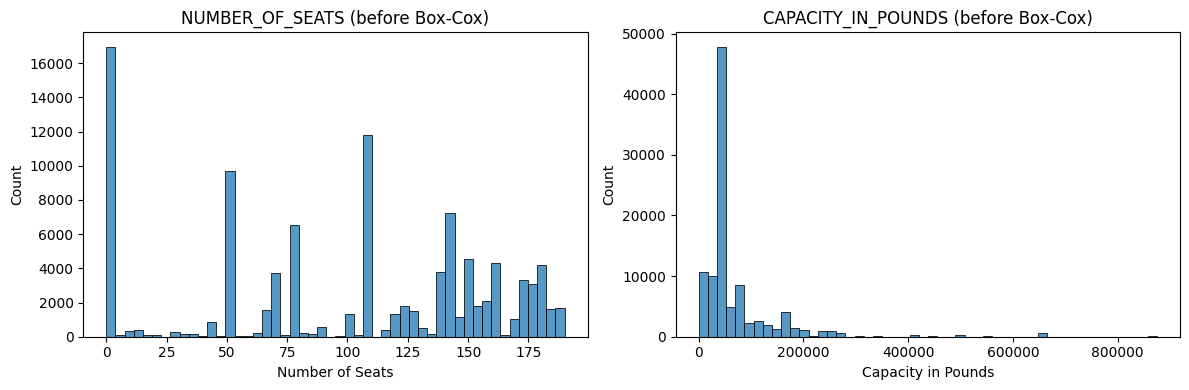

In [307]:
#check skewness and plot before transformation
print('NUMBER_OF_SEATS skewness:    ', df['NUMBER_OF_SEATS'].skew().round(3))
print('CAPACITY_IN_POUNDS skewness: ', df['CAPACITY_IN_POUNDS'].skew().round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['NUMBER_OF_SEATS'], bins=50, ax=axes[0])
axes[0].set_title('NUMBER_OF_SEATS (before Box-Cox)')
axes[0].set_xlabel('Number of Seats')

sns.histplot(df['CAPACITY_IN_POUNDS'], bins=50, ax=axes[1])
axes[1].set_title('CAPACITY_IN_POUNDS (before Box-Cox)')
axes[1].set_xlabel('Capacity in Pounds')

plt.tight_layout()
plt.show()


NUMBER_OF_SEATS (skewness = -0.35):
The distribution has a large spike at 0 seats, which corresponds to cargo aircraft. Beyond that, it shows multiple peaks around 50, 75, and 140–150 seats, reflecting different aircraft types. Although the skewness is slightly negative, the main issue is the spike at 0 and the clearly non-normal shape.

CAPACITY_IN_POUNDS (skewness = 4.253):
This distribution is strongly right-skewed. Most aircraft fall below 100,000 lbs, but a small number of very large aircraft create a long tail. The high skewness confirms this, making it a good candidate for a Box-Cox transformation.  

In [308]:
# Function 10: apply Box-Cox transformation to NUMBER_OF_SEATS and CAPACITY_IN_POUNDS
from scipy.stats import boxcox
def apply_boxcox(df):
    df = df.copy()

    for col in ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']:
        series = df[col].dropna()
        # Box-Cox requires strictly positive values
        if series.min() <= 0:
            series = series + abs(series.min()) + 1

        transformed, lam = boxcox(series)
        new_col = f'{col}_BOXCOX'
        df.loc[df[col].notna(), new_col] = transformed
        print(f'{col}: lambda = {lam:.4f}')

    return df

In [309]:
df = apply_boxcox(df)

NUMBER_OF_SEATS: lambda = 0.6872
CAPACITY_IN_POUNDS: lambda = 0.2964


NUMBER_OF_SEATS_BOXCOX skewness:     -0.714
CAPACITY_IN_POUNDS_BOXCOX skewness:  0.296


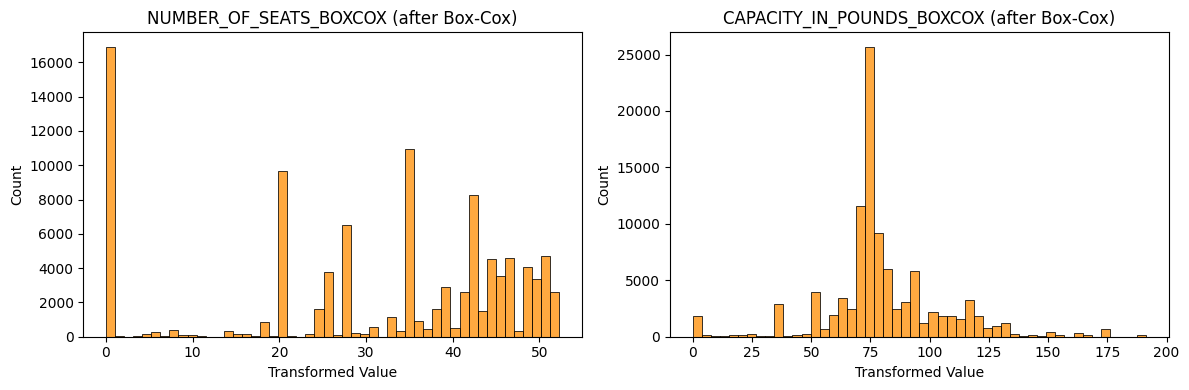

In [310]:
#check skewness and plot after transformation
print('NUMBER_OF_SEATS_BOXCOX skewness:    ', df['NUMBER_OF_SEATS_BOXCOX'].skew().round(3))
print('CAPACITY_IN_POUNDS_BOXCOX skewness: ', df['CAPACITY_IN_POUNDS_BOXCOX'].skew().round(3))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['NUMBER_OF_SEATS_BOXCOX'], bins=50, ax=axes[0], color='darkorange')
axes[0].set_title('NUMBER_OF_SEATS_BOXCOX (after Box-Cox)')
axes[0].set_xlabel('Transformed Value')

sns.histplot(df['CAPACITY_IN_POUNDS_BOXCOX'], bins=50, ax=axes[1], color='darkorange')
axes[1].set_title('CAPACITY_IN_POUNDS_BOXCOX (after Box-Cox)')
axes[1].set_xlabel('Transformed Value')

plt.tight_layout()
plt.show()

**Observations after transformation:**

NUMBER_OF_SEATS_BOXCOX (skewness = -0.714):
The spike at 0 is still there, so the distribution remains uneven. This makes sense since cargo aircraft (0 seats) are a separate group, so Box-Cox doesn’t really help here.

CAPACITY_IN_POUNDS_BOXCOX (skewness = 0.296):
This improved a lot. The distribution is now much more symmetric, and the long right tail is mostly gone.

**Summary:**
Box-Cox works well for CAPACITY_IN_POUNDS but not for NUMBER_OF_SEATS, since the seat data has a built-in split between cargo and passenger aircraft.

## Task 5 — Feature Engineering & Modeling

In [311]:
# Function 11: create SIZE column
def create_size_column(df):
    df = df.copy()
    q1, q2, q3 = df['NUMBER_OF_SEATS'].quantile([0.25, 0.50, 0.75])
    print(f'Q1={q1}, Q2={q2}, Q3={q3}')

    bins   = [-np.inf, q1, q2, q3, np.inf]
    labels = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']
    df['SIZE'] = pd.cut(df['NUMBER_OF_SEATS'], bins=bins, labels=labels)
    print(df['SIZE'].value_counts())
    return df

In [312]:
df = create_size_column(df)

Q1=50.0, Q2=108.0, Q3=150.0
SIZE
SMALL     29323
MEDIUM    25313
LARGE     23461
XLARGE    23190
Name: count, dtype: int64


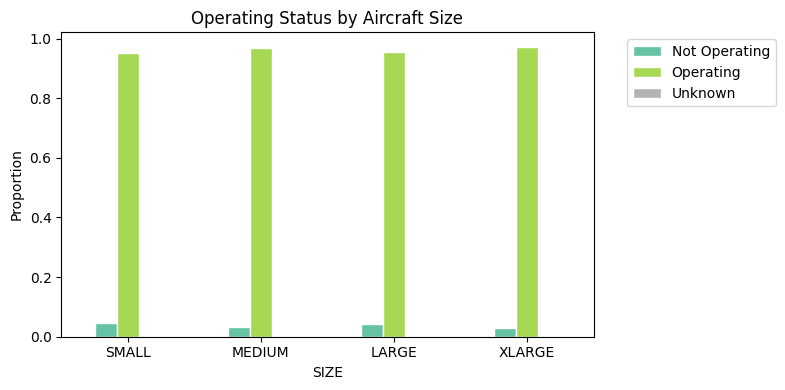

In [313]:
# operating status proportions by SIZE
size_order = ['SMALL', 'MEDIUM', 'LARGE', 'XLARGE']
op_prop = (
    df.groupby(['SIZE', 'OPERATING_STATUS'], observed=True)
      .size().unstack(fill_value=0)
      .reindex(size_order)
)
op_prop = op_prop.div(op_prop.sum(axis=1), axis=0)

op_prop.plot(kind='bar', figsize=(8, 4), colormap='Set2', edgecolor='white')
plt.title('Operating Status by Aircraft Size')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [314]:
op_prop

OPERATING_STATUS,Not Operating,Operating,Unknown
SIZE,,,
SMALL,0.047062,0.952904,0.000034
MEDIUM,0.031920,0.968080,0.000000
LARGE,0.043647,0.956353,0.000000
XLARGE,0.027727,0.972273,0.000000


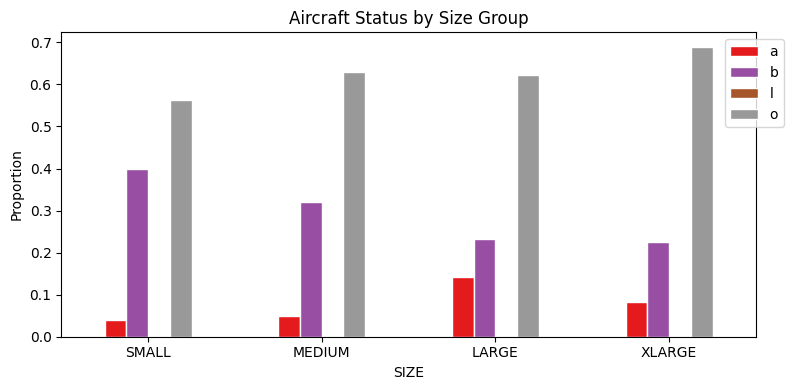

In [315]:
# aircraft status proportions by SIZE
ac_prop = (
    df.groupby(['SIZE', 'AIRCRAFT_STATUS'], observed=True)
      .size().unstack(fill_value=0)
      .reindex(size_order)
)
ac_prop = ac_prop.div(ac_prop.sum(axis=1), axis=0)

ac_prop.plot(kind='bar', figsize=(8, 4), colormap='Set1', edgecolor='white')
plt.title('Aircraft Status by Size Group')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [316]:
ac_prop

AIRCRAFT_STATUS,a,b,l,o
SIZE,,,,
SMALL,0.039321,0.398595,0.000000,0.562084
MEDIUM,0.049619,0.320270,0.000514,0.629597
LARGE,0.142108,0.232769,0.001961,0.623162
XLARGE,0.081673,0.226261,0.002717,0.689349


### Summary of Findings

**Operating Status by Size:**
All size groups have high operating proportions (95–97%). XLARGE has the
highest operating rate (97.2%) and SMALL the lowest (95.3%), with MEDIUM
(96.8%) and LARGE (95.6%) in between.

**Aircraft Status by Size:**
Out-of-service (o) is the dominant status across all size groups, increasing
with size, SMALL (56.2%), MEDIUM (62.9%), LARGE (62.3%), and XLARGE (68.9%).
Stored (b) is most common in smaller aircraft, SMALL (39.9%) and MEDIUM
(32.0%) have notably higher stored proportions than LARGE (23.3%) and XLARGE
(22.6%), suggesting smaller aircraft are more often temporarily parked rather
than permanently retired. Active (a) proportion increases with size, LARGE
(14.2%) and XLARGE (8.2%) are higher than SMALL (3.9%) and MEDIUM (5.0%),
consistent with the operating status finding that larger aircraft are more
likely to remain in active use.

## Task 6 — Modeling refresher

In [317]:
# encode categoricals needed as features
df['SIZE_ENC'] = df['SIZE'].map({'SMALL': 0, 'MEDIUM': 1, 'LARGE': 2, 'XLARGE': 3})
df['MFR_ENC']  = LabelEncoder().fit_transform(df['MANUFACTURER'].fillna('Unknown'))
df['OP_ENC']   = (df['OPERATING_STATUS'] == 'Operating').astype(int)

feature_cols = ['MANUFACTURE_YEAR', 'AIRLINE_ID', 'SIZE_ENC', 'MFR_ENC', 'OP_ENC']

df_model = df[feature_cols + ['NUMBER_OF_SEATS', 'CAPACITY_IN_POUNDS']].dropna()
print(f'Rows available for modeling: {len(df_model):,}')

X = df_model[feature_cols]

Rows available for modeling: 101,287


### 6.1 Model 1 & 2 — Multivariate Regression:


In [318]:
# predict NUMBER_OF_SEATS with multivariate regression
y_seats = df_model['NUMBER_OF_SEATS']
X_train, X_test, y_train, y_test = train_test_split(X, y_seats, test_size=0.2, random_state=42)

lr_seats = LinearRegression()
lr_seats.fit(X_train, y_train)

rmse_train = root_mean_squared_error(y_train, lr_seats.predict(X_train))
rmse_test  = root_mean_squared_error(y_test,  lr_seats.predict(X_test))
print(f'Linear Regression - NUMBER_OF_SEATS')
print(f'  Train RMSE: {rmse_train:.2f}')
print(f'  Test RMSE:  {rmse_test:.2f}')

Linear Regression - NUMBER_OF_SEATS
  Train RMSE: 19.33
  Test RMSE:  19.16


In [319]:
# predict CAPACITY_IN_POUNDS with multivariate regression
y_cap = df_model['CAPACITY_IN_POUNDS']
X_train, X_test, y_train, y_test = train_test_split(X, y_cap, test_size=0.2, random_state=42)

lr_cap = LinearRegression()
lr_cap.fit(X_train, y_train)

rmse_train = root_mean_squared_error(y_train, lr_cap.predict(X_train))
rmse_test  = root_mean_squared_error(y_test,  lr_cap.predict(X_test))
print(f'Linear Regression - CAPACITY_IN_POUNDS')
print(f'  Train RMSE: {rmse_train:.2f}')
print(f'  Test RMSE:  {rmse_test:.2f}')

Linear Regression - CAPACITY_IN_POUNDS
  Train RMSE: 87702.09
  Test RMSE:  88684.37


### 6.2 Model 3 & 4 — Random Forest:


In [320]:
# predict NUMBER_OF_SEATS with random forest
y_seats = df_model['NUMBER_OF_SEATS']
X_train, X_test, y_train, y_test = train_test_split(X, y_seats, test_size=0.2, random_state=42)

rf_seats = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_seats.fit(X_train, y_train)

rmse_train = root_mean_squared_error(y_train, rf_seats.predict(X_train))
rmse_test  = root_mean_squared_error(y_test,  rf_seats.predict(X_test))
print(f'Random Forest - NUMBER_OF_SEATS')
print(f'  Train RMSE: {rmse_train:.2f}')
print(f'  Test RMSE:  {rmse_test:.2f}')

Random Forest - NUMBER_OF_SEATS
  Train RMSE: 3.90
  Test RMSE:  4.04


In [321]:
# predict CAPACITY_IN_POUNDS with random forest
y_cap = df_model['CAPACITY_IN_POUNDS']
X_train, X_test, y_train, y_test = train_test_split(X, y_cap, test_size=0.2, random_state=42)

rf_cap = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_cap.fit(X_train, y_train)

rmse_train = root_mean_squared_error(y_train, rf_cap.predict(X_train))
rmse_test  = root_mean_squared_error(y_test,  rf_cap.predict(X_test))
print(f'Random Forest - CAPACITY_IN_POUNDS')
print(f'  Train RMSE: {rmse_train:.2f}')
print(f'  Test RMSE:  {rmse_test:.2f}')

Random Forest - CAPACITY_IN_POUNDS
  Train RMSE: 45770.61
  Test RMSE:  47080.70


**NUMBER_OF_SEATS:** Random Forest performs much better than Linear
Regression (test RMSE 4.04 vs 19.16), suggesting the relationship
between features and seat count is non-linear. Train and test RMSE
are very close for both models, so there is no sign of overfitting.

**CAPACITY_IN_POUNDS:** Random Forest again outperforms Linear Regression
(test RMSE 47,080 vs 88,684). The larger absolute error values are
expected given the scale of the variable (up to 875,000 lbs). Both
models show a small and normal gap between train and test RMSE.

**Overall:** Random Forest is clearly the stronger model for both targets.
All four models generalize well based on the small train–test gaps,
indicating no overfitting despite the large dataset.